In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [14]:
train = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")

In [15]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [16]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [17]:
train.isnull().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

In [18]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

Note: you may need to restart the kernel to use updated packages.


In [19]:
import dagshub
import mlflow
import mlflow.sklearn

#dagshub.init(repo_owner='YOUR_DAGSHUB_USERNAME', repo_name='YOUR_REPO_NAME', mlflow=True)
dagshub.init(repo_owner='mkapa22', repo_name='ML_Assignment1', mlflow=True)

Initialized MLflow to track repo "mkapa22/ML_Assignment1"

Repository mkapa22/ML_Assignment1 initialized!

In [20]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=["SalePrice"])
y = train["SalePrice"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (1168, 80)
Test size:  (292, 80)


In [23]:
print(X_train.describe())

                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1168.000000  1168.000000   951.000000    1168.000000  1168.000000   
mean    730.904966    56.849315    70.343849   10689.642123     6.121575   
std     425.369088    42.531862    24.897021   10759.366198     1.367619   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     360.750000    20.000000    59.000000    7587.250000     5.000000   
50%     732.500000    50.000000    70.000000    9600.000000     6.000000   
75%    1101.750000    70.000000    80.000000   11700.000000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1168.000000  1168.000000   1168.000000  1162.000000  1168.000000  ...   
mean      5.584760  1970.965753   1984.897260   103.771945   446.023973  ...   
std       1.116062    30.675495     20.733955   173.032238   459.070977  ..

In [24]:
print(X_train.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      217
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
Length: 80, dtype: int64


In [25]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    951 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          74 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallCond

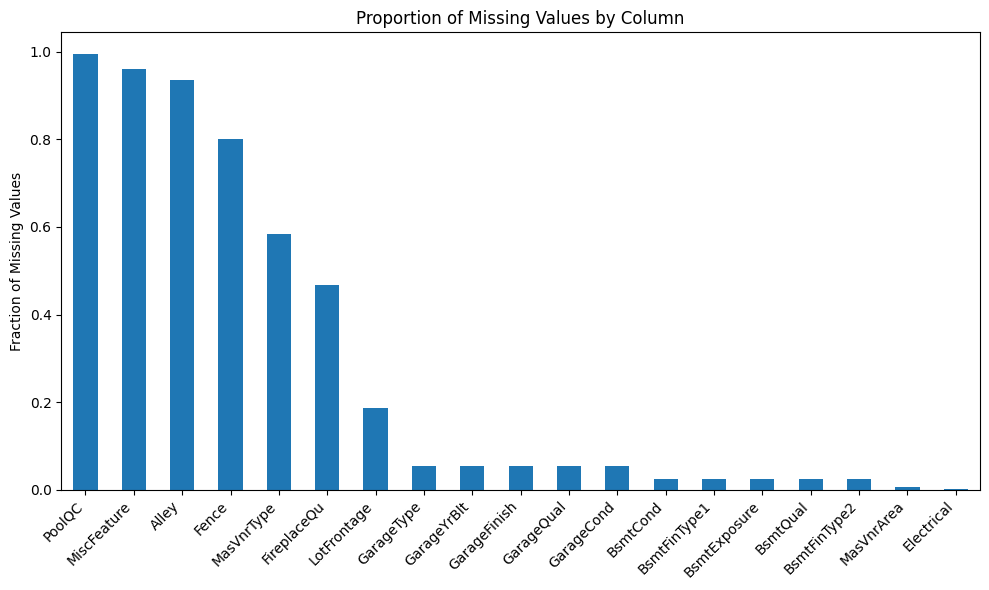

In [26]:
import matplotlib.pyplot as plt

null_ratio = X_train.isna().sum() / X_train.shape[0]
null_ratio = null_ratio[null_ratio > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
null_ratio.plot(kind='bar')
plt.title('Proportion of Missing Values by Column')
plt.ylabel('Fraction of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [27]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns ({len(num_cols)}): {num_cols}")

Categorical columns (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Numerical columns (37): ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageC

<Figure size 1500x1000 with 0 Axes>

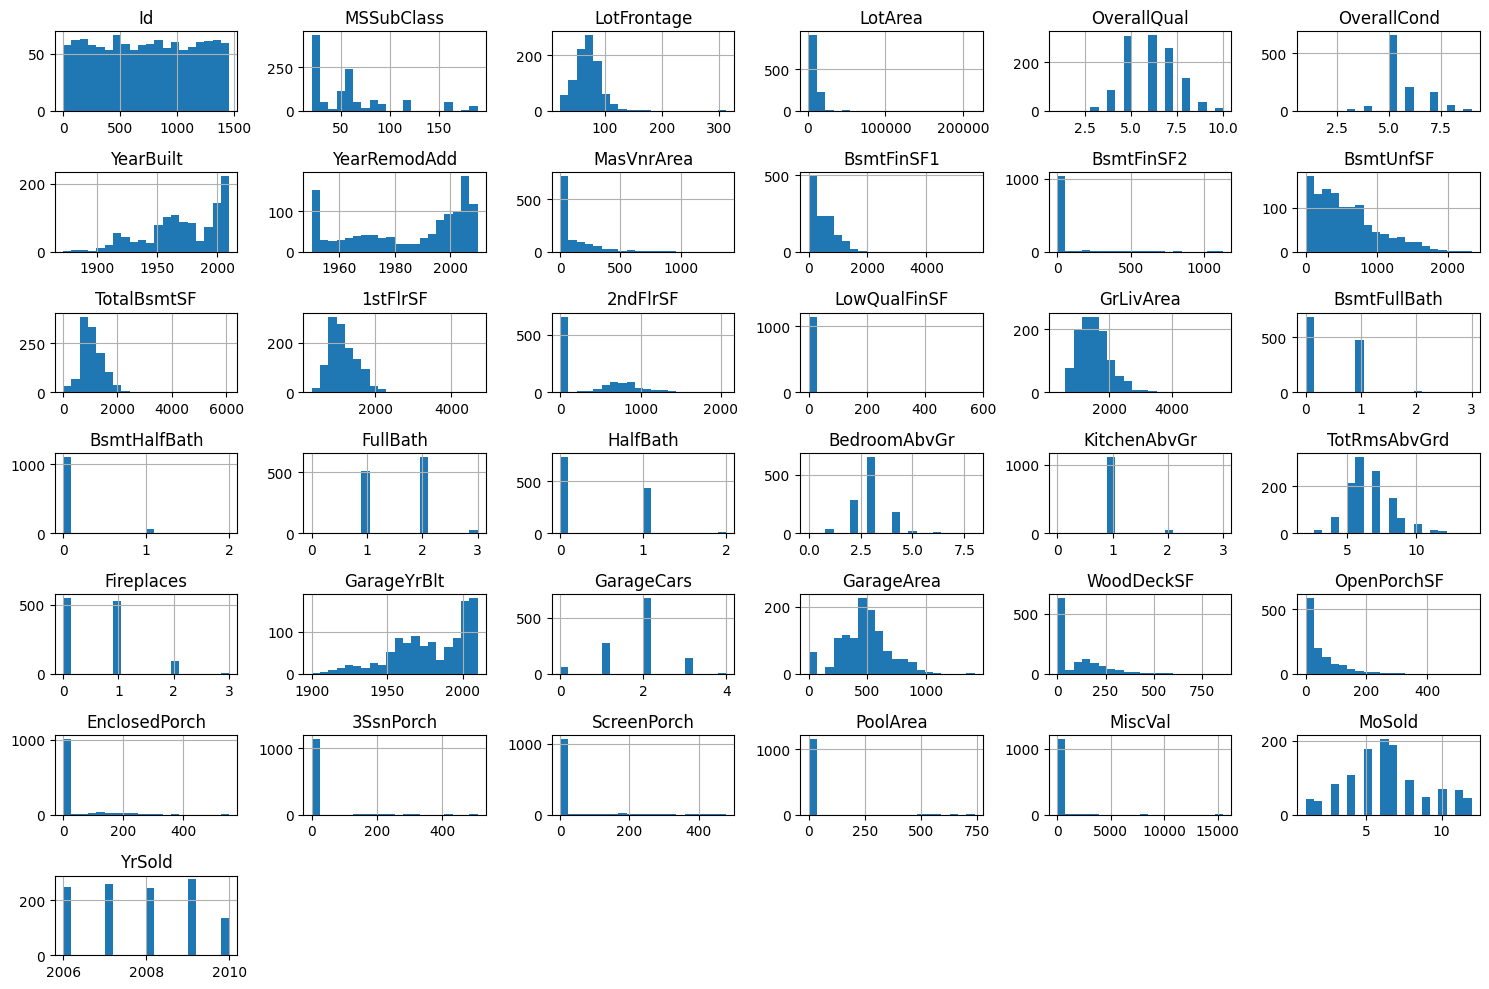

In [28]:
import matplotlib.pyplot as plt

X_train[num_cols].describe()

plt.figure(figsize=(15, 10))
X_train[num_cols].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

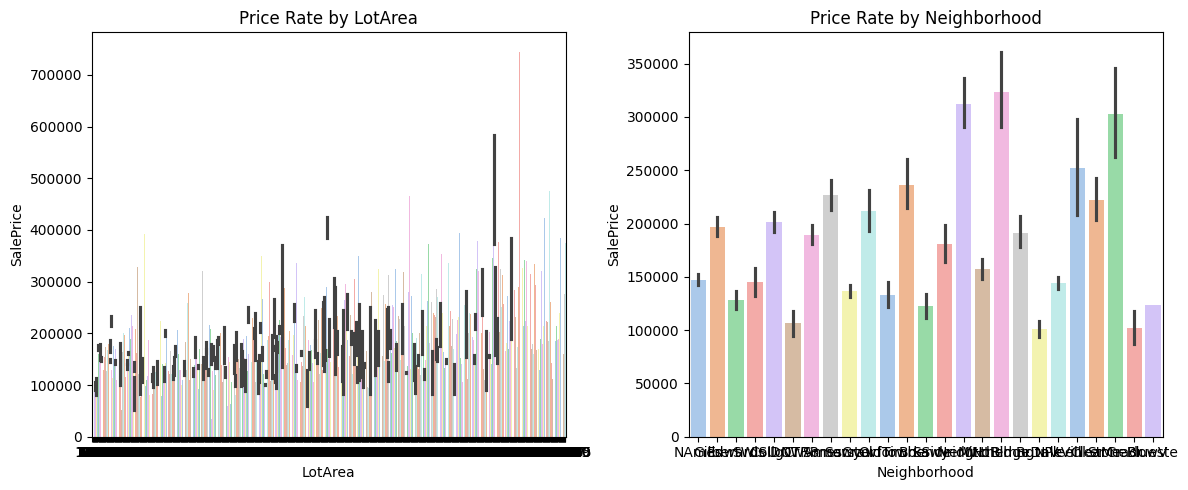

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

train_plot = X_train.copy()
train_plot["SalePrice"] = y_train.values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='LotArea', y='SalePrice', data=train_plot, ax=axes[0], palette='pastel', hue='LotArea', legend=False)
axes[0].set_title('Price Rate by LotArea')
sns.barplot(x='Neighborhood', y='SalePrice', data=train_plot, ax=axes[1], palette='pastel', hue='Neighborhood', legend=False)
axes[1].set_title('Price Rate by Neighborhood')
plt.tight_layout()
plt.show()

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [31]:
for col in X_train.select_dtypes(include=['int64', 'float64']):
    mean_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(mean_val)
    X_test[col] = X_test[col].fillna(mean_val)

In [32]:
for col in X_train.select_dtypes(include=['object']):
    X_train[col] = X_train[col].fillna("None")
    X_test[col] = X_test[col].fillna("None")    

In [33]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [34]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1168, 302), (1168,), (292, 262), (292,))

In [35]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [36]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1168, 302), (1168,), (292, 302), (292,))

In [37]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [38]:
from sklearn.metrics import mean_squared_error
import numpy as np

prob_train = model.predict(X_test)
ev = np.sqrt(mean_squared_error(y_test, prob_train))
print(ev)

65340.37917526963


In [39]:
mlflow.set_experiment("ass1/house prices")

<Experiment: artifact_location='mlflow-artifacts:/eb498f83f27f4efdbeb1dd5c9748eac7', creation_time=1775931758419, experiment_id='1', last_update_time=1775931758419, lifecycle_stage='active', name='ass1/house prices', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [ ]:
from sklearn.tree import DecisionTreeRegressor

with mlflow.start_run(run_name="Decision tree depth 10"):

    model = DecisionTreeRegressor(max_depth=10, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    ev = np.sqrt(mean_squared_error(y_test, preds))

    mlflow.log_param("model", "DecisionTree")
    mlflow.log_param("max_depth", 10)
    mlflow.log_metric("ev", ev)

    print("ev:", ev)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

with mlflow.start_run(run_name="linear regression with median"):
    model = LinearRegression()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    ev = np.sqrt(mean_squared_error(y_test, preds))
    mlflow.log_param("model", "LinearRegression")
    mlflow.log_param("fill_numeric", "median")
    mlflow.log_param("fill_categorical", "None")
    mlflow.log_metric("ev", ev)

    mlflow.sklearn.log_model(model, "model")

    print("ev:", ev)

In [40]:
X_train["TotalSF"] = X_train["TotalBsmtSF"] + X_train["1stFlrSF"] + X_train["2ndFlrSF"]
X_test["TotalSF"] = X_test["TotalBsmtSF"] + X_test["1stFlrSF"] + X_test["2ndFlrSF"]

In [41]:
from sklearn.tree import DecisionTreeRegressor

with mlflow.start_run(run_name="Decision tree depth 5 with new features "):

    model = DecisionTreeRegressor(max_depth=5, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    ev = np.sqrt(mean_squared_error(y_test, preds))

    mlflow.log_param("model", "DecisionTree")
    mlflow.log_param("max_depth", 5)
    mlflow.log_metric("ev", ev)

    print("ev:", ev)

ev: 38959.74100689775
🏃 View run Decision tree depth 5 with new features  at: https://dagshub.com/mkapa22/ML_Assignment1.mlflow/#/experiments/1/runs/673836311a3c442f9379519c06d5c1cb
🧪 View experiment at: https://dagshub.com/mkapa22/ML_Assignment1.mlflow/#/experiments/1


In [42]:
X_train = X_train.drop(["Id"], axis=1)
X_test = X_test.drop(["Id"], axis=1)

In [43]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1168, 302), (1168,), (292, 302), (292,))

In [44]:
from sklearn.tree import DecisionTreeRegressor

with mlflow.start_run(run_name="Decision tree depth 6 with id dropped "):

    model = DecisionTreeRegressor(max_depth=6, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    ev = np.sqrt(mean_squared_error(y_test, preds))

    mlflow.log_param("model", "DecisionTree")
    mlflow.log_param("max_depth", 6)
    mlflow.log_metric("ev", ev)

    print("ev:", ev)

ev: 37686.34540048263
🏃 View run Decision tree depth 6 with id dropped  at: https://dagshub.com/mkapa22/ML_Assignment1.mlflow/#/experiments/1/runs/0a823cd0f64141b09a10818b86fcfc74
🧪 View experiment at: https://dagshub.com/mkapa22/ML_Assignment1.mlflow/#/experiments/1


In [45]:
X_train_orig = X_train.copy()
X_test_orig = X_test.copy()

In [46]:
from sklearn.tree import DecisionTreeRegressor

with mlflow.start_run(run_name="Decision tree depth 7 with id dropped +feature"):

    model = DecisionTreeRegressor(max_depth=7, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    ev = np.sqrt(mean_squared_error(y_test, preds))

    mlflow.log_param("model", "DecisionTree")
    mlflow.log_param("max_depth", 7)
    mlflow.log_metric("ev", ev)

    print("ev:", ev)

ev: 40446.48149898557
🏃 View run Decision tree depth 7 with id dropped +feature at: https://dagshub.com/mkapa22/ML_Assignment1.mlflow/#/experiments/1/runs/a3832e795e4542f79cb49d4c9e3c810b
🧪 View experiment at: https://dagshub.com/mkapa22/ML_Assignment1.mlflow/#/experiments/1


In [57]:
from sklearn.ensemble import RandomForestRegressor

with mlflow.start_run(run_name="RandomForsetRegressor log estimator 100"):
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    ev = np.sqrt(mean_squared_error(y_test, preds))
    print("ev:", ev)
    
    mlflow.log_param("model", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("ev", ev)


ev: 29928.104948280874
🏃 View run RandomForsetRegressor log estimator 100 at: https://dagshub.com/mkapa22/ML_Assignment1.mlflow/#/experiments/1/runs/bb2017bcbf454cafa312c583362b57e9
🧪 View experiment at: https://dagshub.com/mkapa22/ML_Assignment1.mlflow/#/experiments/1


In [56]:
with mlflow.start_run(run_name="RandomForsetRegressor log estimator 50"):
    model = RandomForestRegressor(n_estimators=50, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    ev = np.sqrt(mean_squared_error(y_test, preds))
    print("ev:", ev)
    
    mlflow.log_param("model", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 50)
    mlflow.log_metric("ev", ev)

ev: 30555.561667556653
🏃 View run RandomForsetRegressor log estimator 50 at: https://dagshub.com/mkapa22/ML_Assignment1.mlflow/#/experiments/1/runs/781eda0111474ceebcccf2993ae819e2
🧪 View experiment at: https://dagshub.com/mkapa22/ML_Assignment1.mlflow/#/experiments/1


In [58]:
with mlflow.start_run(run_name="RandomForsetRegressor log estimator 200"):
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    ev = np.sqrt(mean_squared_error(y_test, preds))
    print("ev:", ev)
    
    mlflow.log_param("model", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("ev", ev)

ev: 29675.77207354942
🏃 View run RandomForsetRegressor log estimator 200 at: https://dagshub.com/mkapa22/ML_Assignment1.mlflow/#/experiments/1/runs/8cda5430efac4144a264aa4cc5f82950
🧪 View experiment at: https://dagshub.com/mkapa22/ML_Assignment1.mlflow/#/experiments/1


In [61]:
with mlflow.start_run(run_name="RandomForsetRegressor log estimator 400"):
    model = RandomForestRegressor(n_estimators=400, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print("rmse:", rmse)
    
    mlflow.log_param("model", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 400)
    mlflow.log_metric("rmse", rmse)

rmse: 29558.12819812276
🏃 View run RandomForsetRegressor log estimator 400 at: https://dagshub.com/mkapa22/ML_Assignment1.mlflow/#/experiments/1/runs/b54a6b42e9b1458d892ef59e93d4cdcb
🧪 View experiment at: https://dagshub.com/mkapa22/ML_Assignment1.mlflow/#/experiments/1


In [60]:
with mlflow.start_run(run_name="RandomForsetRegressor log estimator 500"):
    model = RandomForestRegressor(n_estimators=500, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    ev = np.sqrt(mean_squared_error(y_test, preds))
    print("ev:", ev)
    
    mlflow.log_param("model", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_metric("ev", ev)

ev: 29615.452289184486
🏃 View run RandomForsetRegressor log estimator 500 at: https://dagshub.com/mkapa22/ML_Assignment1.mlflow/#/experiments/1/runs/76dc8e82ca3f4dba88fc8284f6a6bdcc
🧪 View experiment at: https://dagshub.com/mkapa22/ML_Assignment1.mlflow/#/experiments/1


In [62]:
model = RandomForestRegressor(n_estimators=400, random_state=42)
model.fit(X, y)
preds = model.predict(test)
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": preds
})

submission.to_csv("submission.csv", index=False)

ValueError: could not convert string to float: 'RL'

In [67]:
finaltest = pd.concat([X, test])

In [68]:
finaltest = pd.get_dummies(finaltest)

In [69]:
X_processed = full[:len(X)]
test_processed = full[len(X):]

In [70]:
model = RandomForestRegressor(n_estimators=400, random_state=42)
model.fit(X_processed, y)

preds = model.predict(test_processed)

In [71]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": preds
})

submission.to_csv("submission.csv", index=False)